# Soc5044 Computational Sociology W14 Practicum - Text Analysis Part 4

These teaching materials are adpated from [Computational Content Analysis Notebooks](https://github.com/KnowledgeLab/content_analysis/tree/release) (created by [Knowledge Lab](https://knowledgelab.org/) at University of Chicago) for the course "Soc5044 Computational Sociology" lectured at the sociology department of National Taiwan University by Dr. Chen-Shuo Hong.

In particular, this file uses the following chapters:
- "[Week 4 - Word Embeddings](https://github.com/KnowledgeLab/content_analysis/blob/release/4-Word-Embedding/4-Word-Embedding.ipynb)"

Editor: Jun-Wei Liu (b09902009@ntu.edu.tw)

---

# 1. Word Embeddings

This week, we build on last week's topic modeling techniques by taking a text corpus we have developed, specifying an underlying number of dimensions, and training a model with a neural network auto-encoder (one of Google's word2vec  algorithms) that best describes corpus words in their local linguistic contexts, and exploring their locations in the resulting space to learn about the discursive culture that produced them. Documents here are represented as densely indexed locations in dimensions, rather than sparse mixtures of topics (as in LDA topic modeling), so that distances between those documents (and words) are consistently superior, though they require the full vector of dimension loadings (rather than just a few selected topic loadings) to describe. We will explore these spaces to understand complex, semantic relationships between words, index documents with descriptive words, identify the likelihood that a given document would have been produced by a given vector model, and explore how semantic categories can help us understand the cultures that produced them.

For this notebook we will be using the following packages:
- `genism`: for word2vec
- `nltk`: for stop words and stemmers
- `sklearn.manifold`: for T-SNE
- `sklearn.decomposition`: for PCA

In [1]:
!pip install --upgrade pip
!pip install gensim nltk scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Getting our corpora

Instead of downloading our corpora, we have download them in advance; a subset of the [senate press releases](https://github.com/lintool/GrimmerSenatePressReleases) are in `grimmerPressReleases`. We will load them into a DataFrame, but first we need to define a function to convert directories of text files into DataFrames:

In [2]:
import os
import os.path
import pandas as pd

def loadDir(targetDir, category):
    allFileNames = os.listdir(targetDir)
    #We need to make them into useable paths and filter out hidden files
    filePaths = [os.path.join(targetDir, fname) for fname in allFileNames if fname[0] != '.']

    #The dict that will become the DataFrame
    senDict = {
        'category' : [category] * len(filePaths),
        'filePath' : [],
        'text' : [],
    }

    for fPath in filePaths:
        with open(fPath) as f:
            senDict['text'].append(f.read())
            senDict['filePath'].append(fPath)

    return pd.DataFrame(senDict)

Now we can use the function in all the directories in `data/grimmerPressReleases` (take ~1 minute to load all files in 5 directories).

In [3]:
dataDir = 'data/grimmerPressReleases'

senReleasesDF = []

for senatorName in [d for d in os.listdir(dataDir) if d[0] != '.']:
    senPath = os.path.join(dataDir, senatorName)
    senReleasesDF.append(loadDir(senPath, senatorName))

senReleasesDF = pd.concat(senReleasesDF, ignore_index=True)
senReleasesDF[:100:10]

,category,filePath,text
0,Kennedy,data/grimmerPressReleases/Kennedy/01Apr2005Ken...,FOR IMMEDIATE RELEASE FOR IMMEDIATE...
10,Kennedy,data/grimmerPressReleases/Kennedy/01Dec2005Ken...,FOR IMMEDIATE RELEASE Washington ...
20,Kennedy,data/grimmerPressReleases/Kennedy/01Feb2006Ken...,FOR IMMEDIATE RELEASE Fact sheet...
30,Kennedy,data/grimmerPressReleases/Kennedy/01Feb2007Ken...,FOR IMMEDIATE RELEASE Washington ...
40,Kennedy,data/grimmerPressReleases/Kennedy/01Jun2007Ken...,FOR IMMEDIATE RELEASE BOSTON MA Se...
50,Kennedy,data/grimmerPressReleases/Kennedy/01Mar2007Ken...,FOR IMMEDIATE RELEASE Washington ...
60,Kennedy,data/grimmerPressReleases/Kennedy/01May2007Ken...,FOR IMMEDIATE RELEASE The President ...
70,Kennedy,data/grimmerPressReleases/Kennedy/01Nov2007Ken...,FOR IMMEDIATE RELEASE Washington DC...
80,Kennedy,data/grimmerPressReleases/Kennedy/02Aug2006Ken...,FOR IMMEDIATE RELEASE FOR IMMEDIATE ...
90,Kennedy,data/grimmerPressReleases/Kennedy/02Feb2005Ken...,FOR IMMEDIATE RELEASE The Preside...


We also want to remove stop words and stem. Tokenizing requires two steps. Word2Vec needs to retain the sentence structure so as to capture a "continuous bag of words (CBOW)" and all of the skip-grams within a word window. The algorithm tries to preserve the distances induced by one of these two local structures. This is very different from clustering and LDA topic modeling which extract unordered words alone. As such, tokenizing is slightly more involved.

In [4]:
import nltk

def normlizeTokens(tokenLst, stopwordLst = None, stemmer = None, lemmer = None, vocab = None):
    #We can use a generator here as we just need to iterate over it

    #Lowering the case and removing non-words
    workingIter = (w.lower() for w in tokenLst if w.isalpha())

    #Now we can use the semmer, if provided
    if stemmer is not None:
        workingIter = (stemmer.stem(w) for w in workingIter)

    #And the lemmer
    if lemmer is not None:
        workingIter = (lemmer.lemmatize(w) for w in workingIter)

    #And remove the stopwords
    if stopwordLst is not None:
        workingIter = (w for w in workingIter if w not in stopwordLst)
        
    #We will return a list with the stopwords removed
    if vocab is not None:
        vocab_str = '|'.join(vocab)
        workingIter = (w for w in workingIter if re.match(vocab_str, w))
    
    return list(workingIter)

# initialize our stemmer and our stop words
nltk.download('stopwords')
stop_words_nltk = nltk.corpus.stopwords.words('english')
snowball = nltk.stem.snowball.SnowballStemmer('english')
wordnet = nltk.stem.WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/letuvertia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
#Apply our functions, notice each row is a list of lists now
senReleasesDF['tokenized_sents'] = senReleasesDF['text'].apply(lambda x: [nltk.word_tokenize(s) for s in nltk.sent_tokenize(x)])
senReleasesDF['normalized_sents'] = senReleasesDF['tokenized_sents'].apply(lambda x: [normlizeTokens(s, stopwordLst = stop_words_nltk, stemmer = None) for s in x])

senReleasesDF[:100:10]

,category,filePath,text,tokenized_sents,normalized_sents
0,Kennedy,data/grimmerPressReleases/Kennedy/01Apr2005Ken...,FOR IMMEDIATE RELEASE FOR IMMEDIATE...,"[[FOR, IMMEDIATE, RELEASE, FOR, IMMEDIATE, REL...","[[immediate, release, immediate, release, cont..."
10,Kennedy,data/grimmerPressReleases/Kennedy/01Dec2005Ken...,FOR IMMEDIATE RELEASE Washington ...,"[[FOR, IMMEDIATE, RELEASE, Washington, D, C, T...","[[immediate, release, washington, c, today, se..."
20,Kennedy,data/grimmerPressReleases/Kennedy/01Feb2006Ken...,FOR IMMEDIATE RELEASE Fact sheet...,"[[FOR, IMMEDIATE, RELEASE, Fact, sheets, on, B...","[[immediate, release, fact, sheets, bush, plan..."
30,Kennedy,data/grimmerPressReleases/Kennedy/01Feb2007Ken...,FOR IMMEDIATE RELEASE Washington ...,"[[FOR, IMMEDIATE, RELEASE, Washington, D, C, T...","[[immediate, release, washington, c, today, u,..."
40,Kennedy,data/grimmerPressReleases/Kennedy/01Jun2007Ken...,FOR IMMEDIATE RELEASE BOSTON MA Se...,"[[FOR, IMMEDIATE, RELEASE, BOSTON, MA, Senator...","[[immediate, release, boston, senator, edward,..."
50,Kennedy,data/grimmerPressReleases/Kennedy/01Mar2007Ken...,FOR IMMEDIATE RELEASE Washington ...,"[[FOR, IMMEDIATE, RELEASE, Washington, DC, Tod...","[[immediate, release, washington, dc, today, s..."
60,Kennedy,data/grimmerPressReleases/Kennedy/01May2007Ken...,FOR IMMEDIATE RELEASE The President ...,"[[FOR, IMMEDIATE, RELEASE, The, President, is,...","[[immediate, release, president, wrong, veto, ..."
70,Kennedy,data/grimmerPressReleases/Kennedy/01Nov2007Ken...,FOR IMMEDIATE RELEASE Washington DC...,"[[FOR, IMMEDIATE, RELEASE, Washington, DC, Sen...","[[immediate, release, washington, dc, senators..."
80,Kennedy,data/grimmerPressReleases/Kennedy/02Aug2006Ken...,FOR IMMEDIATE RELEASE FOR IMMEDIATE ...,"[[FOR, IMMEDIATE, RELEASE, FOR, IMMEDIATE, REL...","[[immediate, release, immediate, release, impo..."
90,Kennedy,data/grimmerPressReleases/Kennedy/02Feb2005Ken...,FOR IMMEDIATE RELEASE The Preside...,"[[FOR, IMMEDIATE, RELEASE, The, President, gav...","[[immediate, release, president, gave, effecti..."


# Word2Vec

We will be using the gensim implementation of [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Word2Vec).

To load our data our data we give all the sentences to the trainer:

In [15]:
import gensim
senReleasesW2V = gensim.models.word2vec.Word2Vec(senReleasesDF['normalized_sents'].sum())

Inside the word2vec object, each word corresponds to a vector with a length of 100.

In [16]:
print(senReleasesW2V.wv['president'].shape)
senReleasesW2V.wv['president']

(100,)


array([ 0.47633204, -1.2643348 , -1.1699408 , -0.5483359 ,  0.64789253,
       -0.82327205,  0.0669053 ,  4.427105  , -1.2513562 , -0.6518337 ,
       -0.5487638 ,  2.2047594 ,  0.5065362 , -0.67102814,  0.06122555,
        0.28490332, -1.0674669 , -1.1085256 ,  1.6326203 , -3.5795126 ,
        0.05385541, -1.7753117 ,  2.4751256 ,  0.7260812 , -0.6053697 ,
        0.10308708, -0.10477258,  0.02201183, -3.0760405 , -0.59747016,
        1.6460003 , -1.1792969 ,  0.14830966, -1.6382593 ,  2.3197181 ,
       -1.47767   , -0.29671523, -0.7502049 ,  1.016545  , -0.78641796,
       -2.1751955 , -1.7541373 , -3.1982765 ,  0.855483  ,  2.30026   ,
        0.28035468, -0.23051243,  0.44424084,  1.0832225 , -0.18509464,
        0.08716474,  3.0807643 ,  2.2267768 , -1.312725  ,  1.8027585 ,
       -1.1429698 ,  0.08754084, -2.7393813 ,  2.52108   ,  0.21141684,
        0.57531476,  1.0316224 , -0.11946468, -0.75339735, -1.480209  ,
        0.5005172 , -0.5056608 ,  0.11869656, -2.7783916 ,  0.47

If you want the full matrix, `vectors` stores all the vectors (13857 vectors in total):

In [17]:
print(senReleasesW2V.wv.vectors.shape)
senReleasesW2V.wv.vectors[10]

(13857, 100)


array([ 1.1343704 ,  0.2247301 , -0.05805235, -2.193798  , -0.18947278,
       -1.1337821 , -0.99179536,  2.8826945 , -0.74410367, -1.2231597 ,
        3.1153297 , -1.4970602 ,  2.4675684 , -1.3532811 ,  0.29033926,
        1.5140162 ,  0.06036741, -0.7612895 ,  3.2842226 , -1.1756469 ,
       -1.0463886 , -0.6159627 , -0.6217534 , -0.71050143, -2.7562885 ,
        0.4103915 , -0.56095165,  0.31601307,  1.065178  ,  1.3175757 ,
       -0.6338735 ,  0.36378416,  3.126631  ,  1.6401057 , -0.9015903 ,
        1.6203758 ,  0.9334649 ,  0.17007098, -1.1960176 , -0.8921072 ,
       -0.22966234, -0.03135961, -1.0044656 ,  2.1746778 , -2.515061  ,
       -1.3148444 , -1.8144338 ,  0.26672733, -3.082673  ,  0.28505754,
       -0.8397533 ,  0.73048186, -2.745001  ,  0.15629593,  0.26337266,
        0.49771887, -1.2532744 ,  0.24167563,  0.7039938 , -0.6881747 ,
       -1.1216255 ,  0.5649825 ,  0.32331806, -2.1854243 , -2.2853992 ,
        0.4714868 , -0.690325  , -2.6754103 , -0.84619564, -0.73

Then, `index_to_key` stores all the words. We can find which word corresponds to the vector `vectors[10]` above.

In [18]:
senReleasesW2V.wv.index_to_key[10]

'american'

Now we can look at a few things that come from the word vectors. The first is to find similar vectors (cosine similarity):

In [19]:
senReleasesW2V.wv.most_similar('president')

[('administration', 0.7501939535140991),
 ('presidents', 0.7498122453689575),
 ('administrations', 0.6232080459594727),
 ('george', 0.595178484916687),
 ('cheney', 0.5928332209587097),
 ('gop', 0.5115118622779846),
 ('republican', 0.4994884729385376),
 ('responds', 0.4987683892250061),
 ('ronald', 0.4871005713939667),
 ('reject', 0.4810386002063751)]

In [20]:
senReleasesW2V.wv.most_similar('war')

[('disobedience', 0.6479379534721375),
 ('wars', 0.631695568561554),
 ('quagmire', 0.6146276593208313),
 ('afghanistan', 0.6079723238945007),
 ('chaos', 0.6014363169670105),
 ('unresisted', 0.5958242416381836),
 ('militarily', 0.5894558429718018),
 ('battle', 0.5875774025917053),
 ('ticking', 0.5820849537849426),
 ('elsewhere', 0.5682995319366455)]

Find which word least matches the others within a word set (cosine similarity):

In [21]:
senReleasesW2V.wv.doesnt_match(['administration', 'administrations', 'presidents', 'president', 'washington'])

'washington'

Find which word best matches the result of a semantic *equation* (here, we seek the words whose vectors best fit the missing entry from the equation: **X + Y - Z = _**.

In [22]:
senReleasesW2V.wv.most_similar(positive=['clinton', 'republican'], negative = ['democrat'])

[('vetoed', 0.6684141159057617),
 ('bush', 0.6460216641426086),
 ('veto', 0.6114177703857422),
 ('bushs', 0.6094357371330261),
 ('signed', 0.6078223586082458),
 ('blocked', 0.5886191725730896),
 ('signature', 0.5777328014373779),
 ('sign', 0.5721006393432617),
 ('reverse', 0.5621141791343689),
 ('desk', 0.5568830370903015)]

Here we see that **Clinton + Republican - Democrat = Bush**. In other words, in this dataset, **Clinton** is to **Democrat** as **Bush** is to **Republican**. Whoah!

We can also save the vectors for later use:

In [23]:
senReleasesW2V.save("data/senpressreleasesWORD2Vec")

We can also use dimension reduction to visulize the vectors. We will start by selecting a subset we want to plot. Let's look at the top words from the set:

In [24]:
numWords = 50
targetWords = senReleasesW2V.wv.index_to_key[:numWords]

We can then extract their vectors and create our own smaller matrix that preserved the distances from the original:

In [25]:
import numpy as np

wordsSubMatrix = []
for word in targetWords:
    wordsSubMatrix.append(senReleasesW2V.wv[word])
wordsSubMatrix = np.array(wordsSubMatrix)
wordsSubMatrix

array([[ 1.1271244 , -0.34243652,  1.0267681 , ..., -1.1339177 ,
         0.97250366,  1.1892287 ],
       [-0.7078085 ,  1.7727718 , -0.56477654, ..., -0.6925887 ,
        -3.0621443 , -1.4606309 ],
       [-1.8305626 , -0.5758897 , -0.04790405, ..., -0.92994815,
        -0.799411  ,  0.83619845],
       ...,
       [-0.4004453 , -0.14485198, -0.254634  , ..., -1.4637266 ,
        -0.6133428 , -1.6804461 ],
       [-0.14228684,  0.6901888 ,  0.7141341 , ...,  0.47313482,
        -1.7339455 , -0.7600444 ],
       [-0.83566046, -1.2666893 ,  1.5320172 , ..., -2.0651257 ,
        -0.8526772 , -1.2803022 ]], dtype=float32)

Then we can use PCA to reduce the dimesions (e.g., from 100 to 50), and T-SNE to project them down to the two we will visualize. We note that this is nondeterministic process, and so you can repeat and achieve alternative projectsions/visualizations of the words:

In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA
pcaWords = PCA(n_components=50).fit(wordsSubMatrix)
reducedPCA_data = pcaWords.transform(wordsSubMatrix)

# T-SNE
tsneWords = TSNE(n_components=2).fit_transform(reducedPCA_data)

We now can plot the points

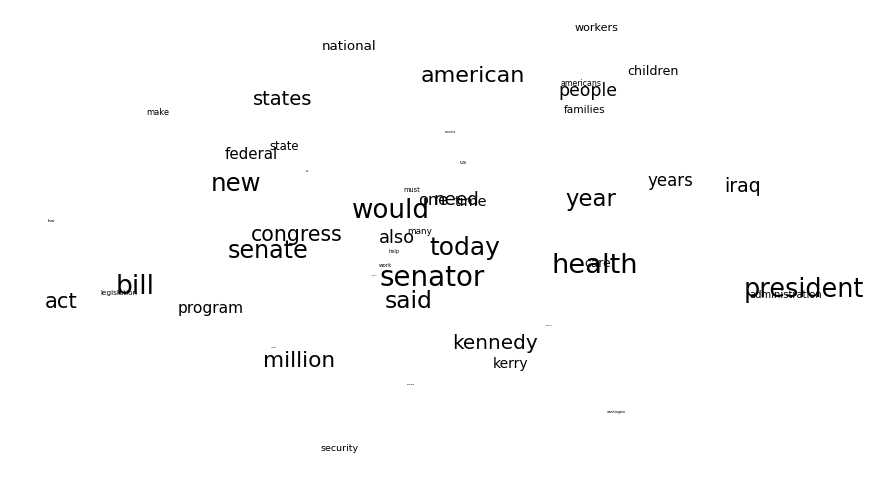

In [27]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWords[:, 0], tsneWords[:, 1], alpha = 0) # Making the points invisible 
for i, word in enumerate(targetWords):
    ax.annotate(word, (tsneWords[:, 0][i],tsneWords[:, 1][i]), size =  20 * (numWords - i) / numWords)
plt.xticks(())
plt.yticks(())
plt.show()

The visualization above puts `president` next to `administration`, `senator` and `senate` near `congress`, and `health` beside `care`.

## Your Turn!

To-do:
1. Build a word2vec model with your corpus.
1. Interrogate word relationships in the resulting space.
1. Plot a subset of your words.

Reflection:
- What do these word relationships reveal about the *social* and *cultural game* underlying your corpus?
- What was surprising -- what violated your prior understanding of the corpus?
- What was expected -- what confirmed your knowledge about this domain?

# 2. Doc2Vec

Instead of just looking at just how words embed within in the space, we can look at how the different documents relate to each other within the space. First lets load our data -- abstracts of most U.S. physics papers from the 1950s.

In [40]:
apsDF = pd.read_csv('data/APSabstracts1950s.csv', index_col = 0)
apsDF[:10]

,copyrightYear,doi,abstract
0,1950,10.1103/RevModPhys.22.221,A summarizing account is given of the research...
1,1951,10.1103/RevModPhys.23.147,New tables of coulomb functions are presented ...
2,1951,10.1103/RevModPhys.23.185,Ionization by electron impact in diatomic gase...
3,1951,10.1103/RevModPhys.23.203,It is shown that the conductivity in the ohmic...
4,1951,10.1103/RevModPhys.23.21,The factorization method is an operational pro...
5,1951,10.1103/RevModPhys.23.311,A brief account is given of Dyson's proof of t...
6,1951,10.1103/RevModPhys.23.315,A systematics is given of all transitions for ...
7,1951,10.1103/RevModPhys.23.322,A systematics of the -transitions of even A nu...
8,1951,10.1103/RevModPhys.23.328,The available experiments on the absorption sp...
9,1952,10.1103/RevModPhys.24.108,The classical theory of the dynamics of viscou...


We will load these as documents into Word2Vec, but first we need to normalize and pick some tags

In [41]:
keywords = ['photomagnetoelectric', 'quantum', 'boltzmann', 'proton', 'positron', 'feynman', 'classical', 'relativity']

In [42]:
apsDF['tokenized_words'] = apsDF['abstract'].apply(lambda x: nltk.word_tokenize(x))
apsDF['normalized_words'] = apsDF['tokenized_words'].apply(lambda x: normlizeTokens(x, stopwordLst = stop_words_nltk))

In [43]:
from gensim.models.doc2vec import TaggedDocument

taggedDocs = []
for index, row in apsDF.iterrows():
    # Just doing a simple keyword assignment
    docKeywords = [s for s in keywords if s in row['normalized_words']]
    docKeywords.append(row['copyrightYear'])
    docKeywords.append(row['doi'])  # This lets us extract individual documents since DOIs are unique
    taggedDocs.append(TaggedDocument(words=row['normalized_words'], tags=docKeywords))

apsDF['TaggedAbstracts'] = taggedDocs

Now we can train a Doc2Vec model:

In [44]:
apsD2V = gensim.models.doc2vec.Doc2Vec(apsDF['TaggedAbstracts'], vector_size = 100) # Limiting to 100 dimensions

We can get vectors for the tags/documents, just as we did with words. Documents are actually the centroids (high dimensional average points) of their words. 

In [45]:
apsD2V.dv[1952]

array([ 0.02057498, -1.1390865 , -3.8717153 ,  0.29226086,  1.9637564 ,
        1.40497   , -1.1843284 ,  0.41740766,  0.65962267, -0.5974636 ,
       -1.5373821 , -0.5595861 , -0.30528474,  0.4262399 , -1.2397982 ,
        0.69619405,  0.6847483 , -1.1507331 , -0.47452638, -0.15361722,
        1.659597  ,  1.2350171 , -1.1821834 ,  0.7115922 , -2.4000895 ,
        0.595832  , -0.35850865, -0.0163636 ,  0.21436001,  0.262282  ,
        1.6279054 ,  0.5519623 , -0.83083105,  0.7232925 , -0.86311156,
        0.8276007 , -0.09692264,  0.04558292, -0.27006185, -0.9463089 ,
        1.5666595 ,  0.13405584, -1.0623273 , -0.4151731 ,  0.8189715 ,
        0.25134972, -0.9222297 ,  0.96737176, -0.14746661, -0.4760671 ,
       -0.35807797, -0.21295886,  1.1532977 ,  0.15750907, -1.6011661 ,
       -0.75995046, -1.1853421 , -0.8291903 ,  0.64313537, -0.1137632 ,
       -1.7611188 ,  0.38836867,  0.787487  ,  1.0593377 , -1.064695  ,
       -1.0529239 ,  0.04551796, -0.45550582, -1.6751902 ,  1.43

The words can still be accessed in the same way:

In [46]:
apsD2V['atom']

array([ 0.7921449 , -0.17337996, -0.5474725 ,  0.63415134, -1.0215406 ,
       -0.7646962 , -2.4531143 , -0.3514713 , -0.2958934 , -0.15007088,
        0.63408357, -0.8057439 ,  0.24912253,  0.1641097 ,  0.45632774,
        0.33161464, -0.47641182,  0.1795982 ,  1.7262223 ,  0.20831692,
        0.03918264, -0.36692664, -0.08096813, -0.36354393, -1.5404413 ,
        0.51846516, -1.615519  , -0.07649378,  1.6975887 , -0.00676584,
        0.5394811 , -1.1394165 ,  0.12830588,  1.531154  , -1.8873321 ,
       -1.4716052 , -0.11493717, -0.65783495, -1.2312635 ,  1.07477   ,
       -0.9522836 ,  1.235736  ,  0.31687218,  0.07573448, -0.38240588,
       -0.18376766, -1.4928496 , -0.19415298, -0.883014  , -0.19731933,
        1.6804506 ,  0.3577178 ,  0.19506846,  0.13095403, -0.6316162 ,
       -0.79949236, -1.0096853 ,  0.48149315,  0.21534528, -0.4242346 ,
       -0.43164703, -0.05426025, -0.7098334 ,  0.8988329 ,  0.4085228 ,
       -1.0096654 ,  1.5060698 ,  0.19754295, -0.47273326,  1.73

We can still use the ``most_similar`` command to perform simple semantic equations:

In [47]:
apsD2V.wv.most_similar(positive = ['atom','electrons'], negative = ['electron'], topn = 1)

[('atoms', 0.7538526654243469)]

This is interesting. **Electron** is to **electrons** as **atom** is to **atoms**. Another way to understand this, developed below is: **electrons - electron** induces a singular to plural dimension, so when we subtract **electron** from **atom** and add **electrons**, we get **atoms**! 

In [48]:
apsD2V.wv.most_similar(positive = ['einstein','law'], negative = ['equation'], topn = 1)

[('london', 0.8319866061210632)]

In other words **Einstein** minus **equation** plus **law** equals **Meissner**--Walthur Meissner studied mechanical engineering and physics ... and was more likely to produce a "law" than a "equation", like the Meissner effect, the damping of the magnetic field in superconductors. If we built our word-embedding with a bigger corpus like the entire arXiv, a massive repository of physics preprints, we would see many more such relationships like **gravity - Newton + Einstein = relativity**.

We can also compute all of these *by hand* -- explicitly wth vector algebra: 

In [49]:
from sklearn.metrics.pairwise import cosine_similarity

# We reorient the vectors with .reshape(1, -1) so that they can be computed without a warning in sklearn
cosine_similarity(apsD2V['electron'].reshape(1,-1), apsD2V['positron'].reshape(1,-1))

array([[0.48625594]], dtype=float32)

In the doc2vec model, the documents have vectors just as the words do, so that we can compare documents with each other and also with words (similar to how a search engine locates a webpage with a query). First, we will calculate the distance between a word and documents in the dataset:

In [ ]:
apsD2V.dv.most_similar([apsD2V['electron']], topn=5 )

[('10.1103/PhysRev.94.910', 0.46434733271598816),
 ('10.1103/PhysRev.113.1547', 0.46322256326675415),
 ('10.1103/PhysRev.101.1467', 0.42302659153938293),
 ('10.1103/PhysRev.113.1545', 0.41834622621536255),
 ('10.1103/PhysRev.106.874', 0.41802114248275757)]

If we search for the first of these on the web (these are doi codes), we find the following ... a pretty good match:

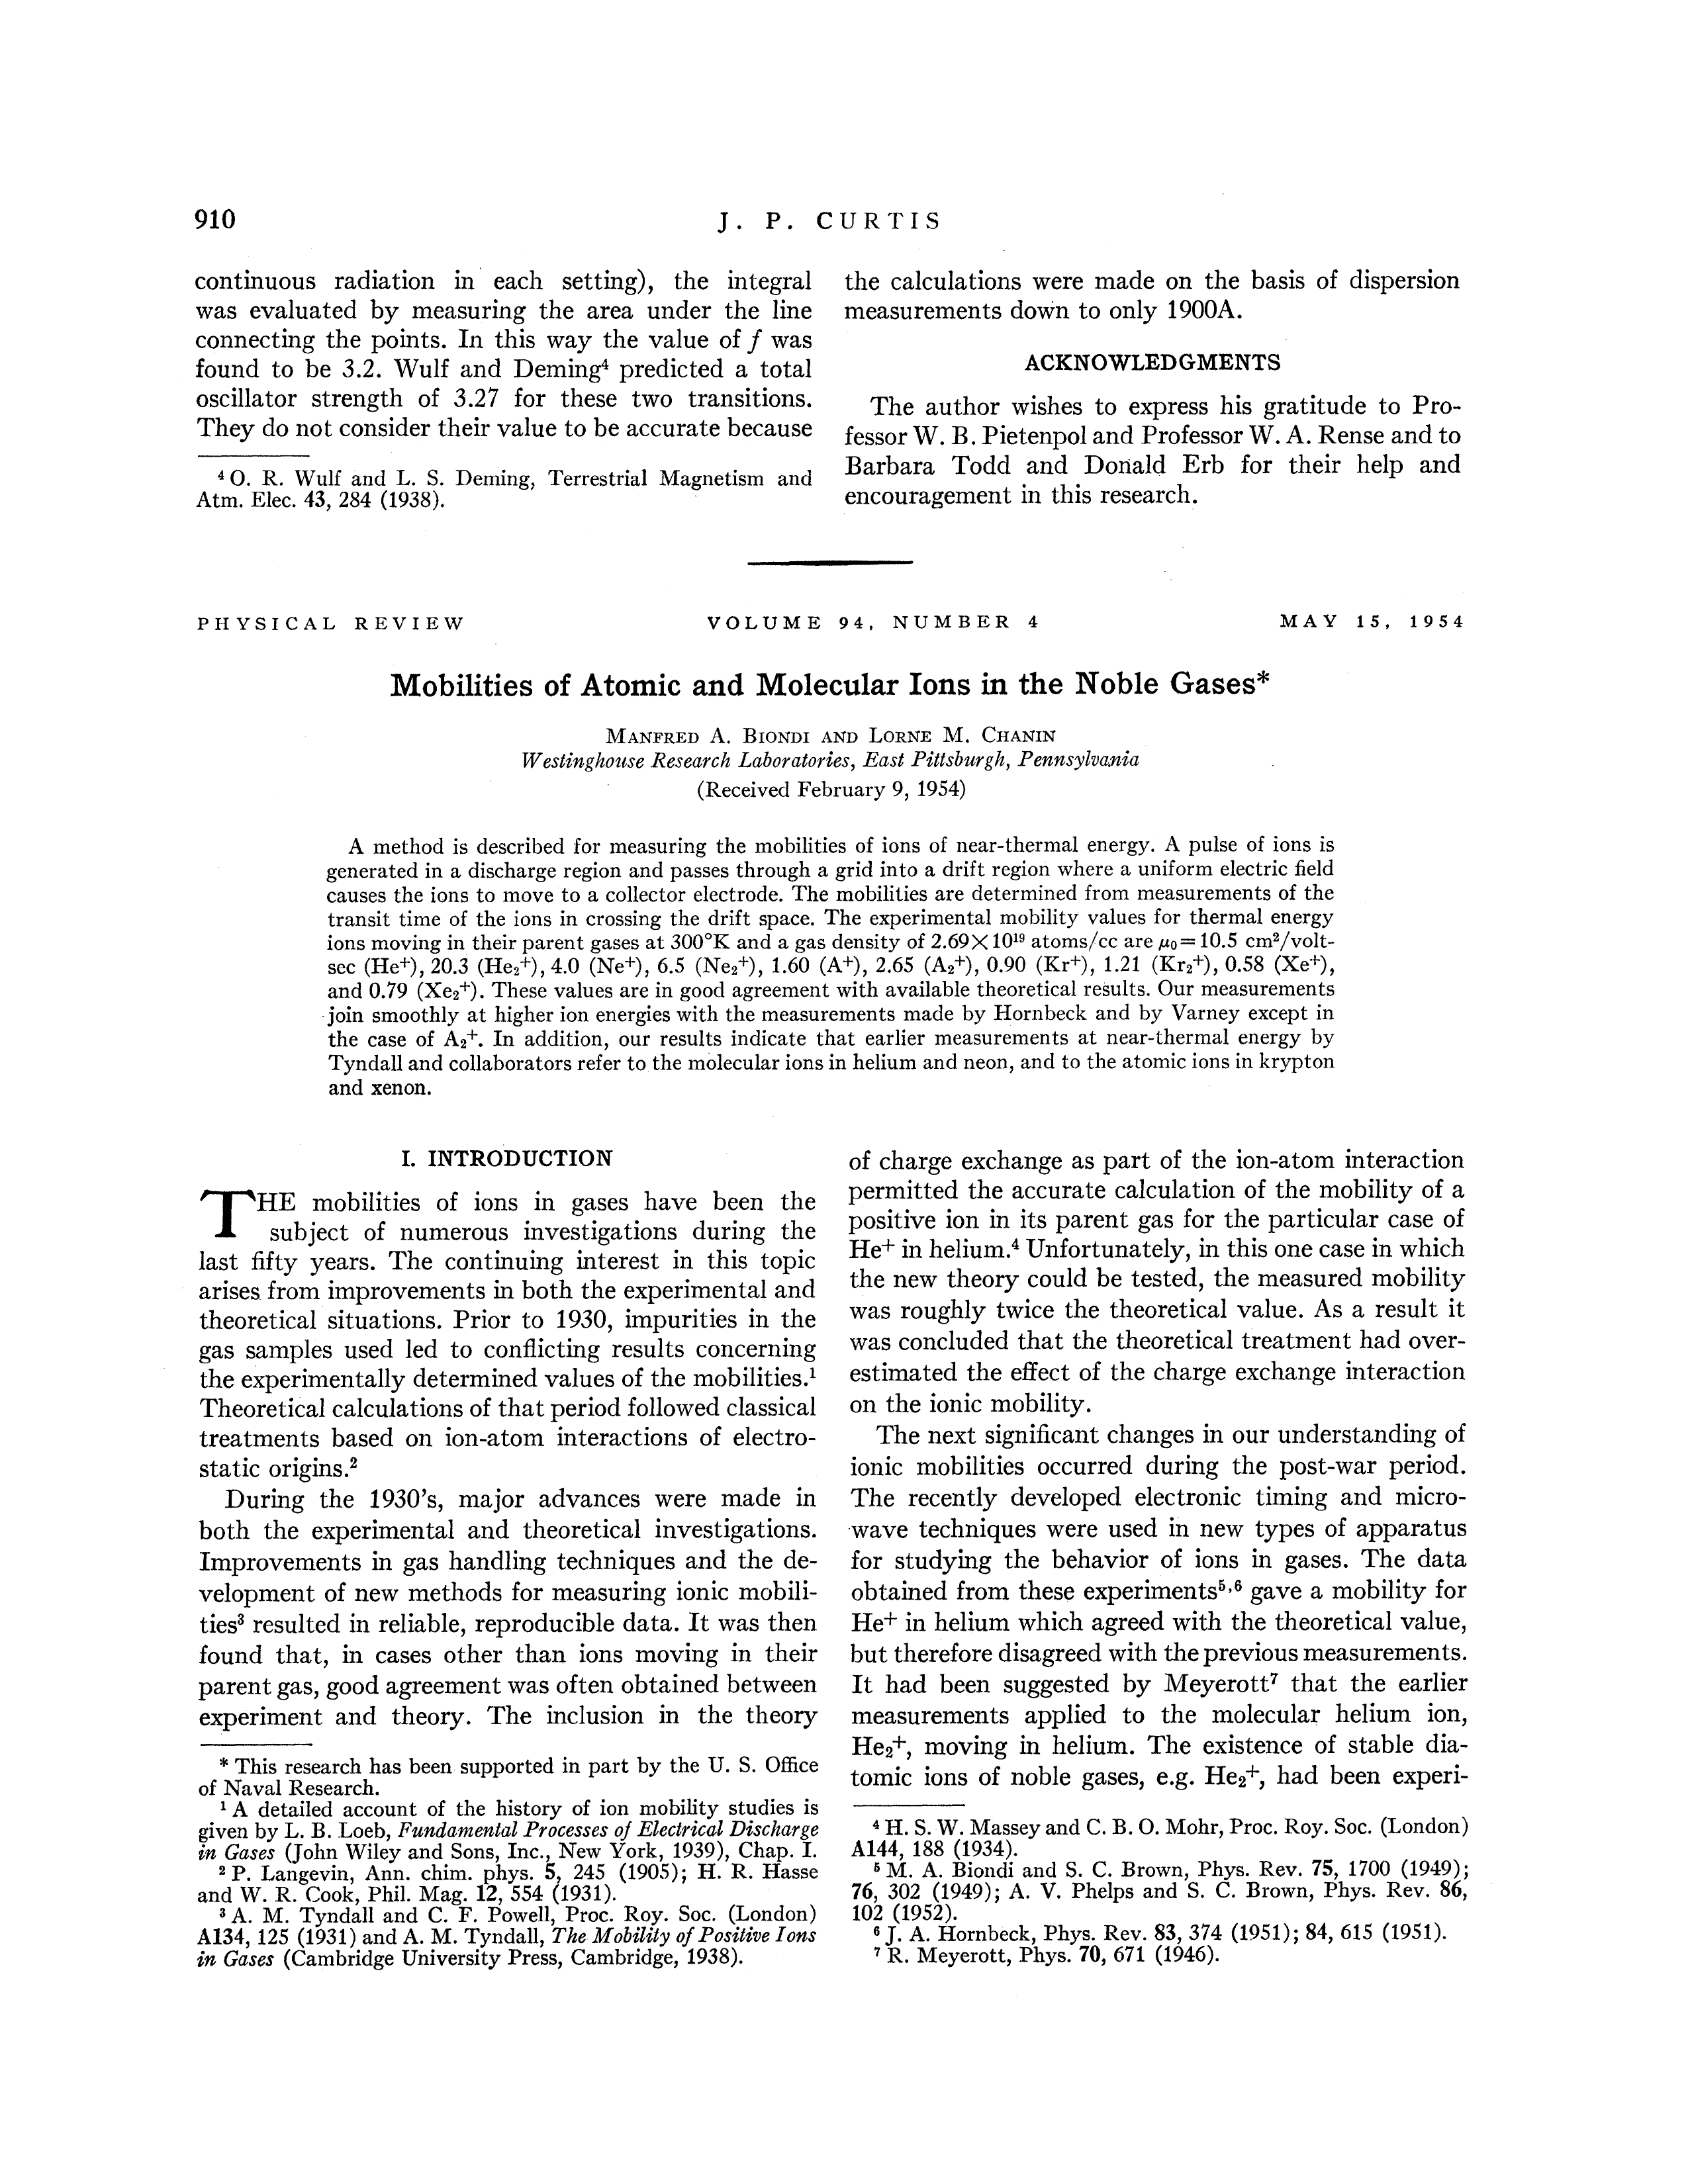

In [51]:
from IPython.display import Image

Image("data/PhysRev.94.910.jpg", width=1000, height=1000)

Now let's go the other way around and find words most similar to this document:

In [52]:
apsD2V.dv.most_similar([apsD2V.dv['10.1103/PhysRev.94.910']], topn=5) 

[('10.1103/PhysRev.94.910', 1.0),
 ('10.1103/PhysRev.105.46', 0.6746168732643127),
 ('10.1103/PhysRev.96.1466', 0.6332870721817017),
 ('10.1103/PhysRev.78.656', 0.6278707981109619),
 ('10.1103/PhysRev.91.289', 0.6258991360664368)]

We can even look for documents most like a query composed of multiple words:

In [53]:
apsD2V.dv.most_similar([apsD2V['electron'] + apsD2V['positron'] + apsD2V['neutron']], topn=5)

[('10.1103/PhysRev.98.1489', 0.4974784553050995),
 ('10.1103/PhysRev.93.524', 0.48985186219215393),
 ('10.1103/PhysRev.100.1364', 0.48520994186401367),
 ('10.1103/PhysRev.91.885', 0.4850994944572449),
 ('10.1103/PhysRev.109.888', 0.4838293194770813)]

Now let's plot some words and documents against one another with a heatmap:

In [54]:
heatmapMatrix = []
for tagOuter in keywords:
    column = []
    tagVec = apsD2V.dv[tagOuter].reshape(1, -1)
    for tagInner in keywords:
        column.append(cosine_similarity(tagVec, apsD2V.dv[tagInner].reshape(1, -1))[0][0])
    heatmapMatrix.append(column)
heatmapMatrix = np.array(heatmapMatrix)

In [55]:
heatmapMatrix.shape

(8, 8)

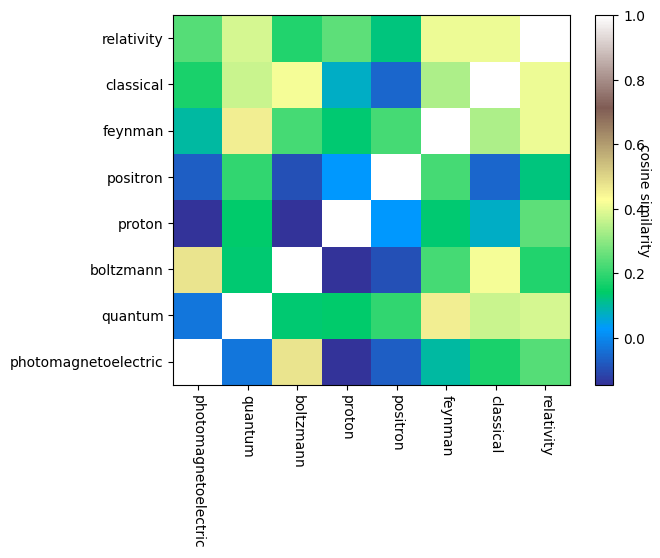

In [56]:
fig, ax = plt.subplots()
hmap = ax.pcolor(heatmapMatrix, cmap='terrain')
cbar = plt.colorbar(hmap)

cbar.set_label('cosine similarity', rotation=270)
a = ax.set_xticks(np.arange(heatmapMatrix.shape[1]) + 0.5, minor=False)
a = ax.set_yticks(np.arange(heatmapMatrix.shape[0]) + 0.5, minor=False)

a = ax.set_xticklabels(keywords, minor=False, rotation=270)
a = ax.set_yticklabels(keywords, minor=False)

Now let's look at a heatmap of similarities between the first ten documents in the corpus:

In [57]:
targetDocs = apsDF['doi'][:10]

heatmapMatrixD = []

for tagOuter in targetDocs:
    column = []
    tagVec = apsD2V.dv[tagOuter].reshape(1, -1)
    for tagInner in targetDocs:
        column.append(cosine_similarity(tagVec, apsD2V.dv[tagInner].reshape(1, -1))[0][0])
    heatmapMatrixD.append(column)
heatmapMatrixD = np.array(heatmapMatrixD)

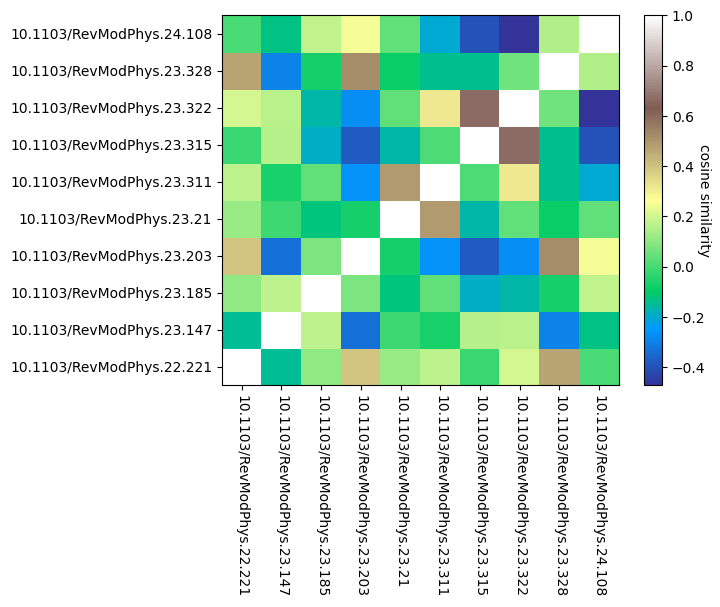

In [58]:
fig, ax = plt.subplots()
hmap = ax.pcolor(heatmapMatrixD, cmap='terrain')
cbar = plt.colorbar(hmap)

cbar.set_label('cosine similarity', rotation=270)
a = ax.set_xticks(np.arange(heatmapMatrixD.shape[1]) + 0.5, minor=False)
a = ax.set_yticks(np.arange(heatmapMatrixD.shape[0]) + 0.5, minor=False)

a = ax.set_xticklabels(targetDocs, minor=False, rotation=270)
a = ax.set_yticklabels(targetDocs, minor=False)

Now let's look at a heatmap of similarities between the first ten documents and our keywords:

In [59]:
heatmapMatrixC = []

for tagOuter in targetDocs:
    column = []
    tagVec = apsD2V.dv[tagOuter].reshape(1, -1)
    for tagInner in keywords:
        column.append(cosine_similarity(tagVec, apsD2V.dv[tagInner].reshape(1, -1))[0][0])
    heatmapMatrixC.append(column)
heatmapMatrixC = np.array(heatmapMatrixC)

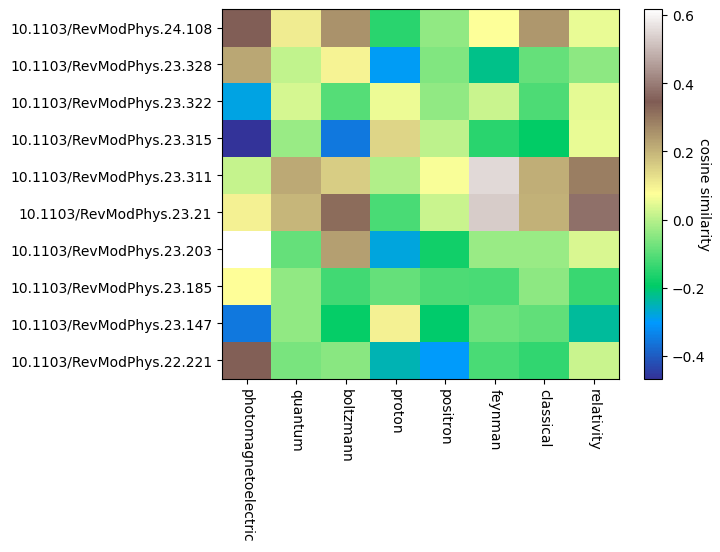

In [60]:
fig, ax = plt.subplots()
hmap = ax.pcolor(heatmapMatrixC, cmap='terrain')
cbar = plt.colorbar(hmap)

cbar.set_label('cosine similarity', rotation=270)
a = ax.set_xticks(np.arange(heatmapMatrixC.shape[1]) + 0.5, minor=False)
a = ax.set_yticks(np.arange(heatmapMatrixC.shape[0]) + 0.5, minor=False)

a = ax.set_xticklabels(keywords, minor=False, rotation=270)
a = ax.set_yticklabels(targetDocs, minor=False)

We will save the model in case we would like to use it again.

In [61]:
apsD2V.save('data/apsW2V')

We can later load it:

In [62]:
# apsD2V = gensim.models.word2vec.Word2Vec.load('data/apsW2V')

## Your Turn!

To-do:
1. Build a doc2vec model with your corpus.
1. Interrogate document and word relationships in the resulting space.
1. Construct a heatmap that plots the distances between a subset of your documents against each other, and against a set of informative words.
1. Find distances between *every* document in your corpus and a word or query of interest.
1. Demonstrate and document one reasonable way to select a defensible subset of query-relevant documents for subsequent analysis.

Reflection:
- What do these doc-doc proximities reveal about your corpus?
- What do these word-doc proximities highlight?

# 3. Projection

We can also project word vectors to an arbitray semantic dimension. To demonstrate this possibility, let's first load a model trained with New York Times news articles. 

In [ ]:
# Take ~1 minute to load
nytimes_model = gensim.models.KeyedVectors.load_word2vec_format('data/nytimes_cbow.reduced.txt', binary=False)

First we can visualize with dimension reduction

In [97]:
# words to create dimensions
tnytTargetWords = ['man','him','he', 'woman', 'her', 'she', 'black','blacks','African', 'white', 'whites', 'Caucasian', 'rich', 'richer', 'richest', 'expensive', 'wealthy', 'poor', 'poorer', 'poorest', 'cheap', 'inexpensive']

# words we will be mapping
tnytTargetWords += ["doctor","lawyer","plumber","scientist","hairdresser", "nanny","carpenter","entrepreneur","musician","writer", "banker","poet","nurse", "steak", "bacon", "croissant", "cheesecake", "salad", "cheeseburger", "vegetables", "beer", "wine", "pastry", "basketball", "baseball", "boxing", "softball", "volleyball", "tennis", "golf", "hockey", "soccer"]


wordsSubMatrix = []
for word in tnytTargetWords:
    wordsSubMatrix.append(nytimes_model[word])
wordsSubMatrix = np.array(wordsSubMatrix)
wordsSubMatrix

array([[-0.343139, -0.117117, -0.50773 , ..., -0.995696,  0.921299,
         0.943769],
       [-0.362909, -0.263528,  0.032661, ..., -0.043032, -0.178965,
         0.353556],
       [-0.70167 , -0.344525, -0.320714, ...,  0.009001,  0.11055 ,
         0.751077],
       ...,
       [-2.391626, -1.90143 ,  1.031182, ...,  2.947464,  1.01588 ,
         2.00033 ],
       [-2.432387, -1.161415,  1.060064, ...,  4.402381,  0.500471,
         1.644596],
       [ 0.981931,  0.628094, -0.747547, ...,  1.612927,  1.148063,
         1.063776]], dtype=float32)

In [ ]:
pcaWordsNYT = PCA(n_components=50).fit(wordsSubMatrix)
reducedPCA_dataNYT = pcaWordsNYT.transform(wordsSubMatrix)
tsneWordsNYT = TSNE(n_components=2).fit_transform(reducedPCA_dataNYT)

In [99]:
tsneWordsNYT[:,1].shape

(54,)

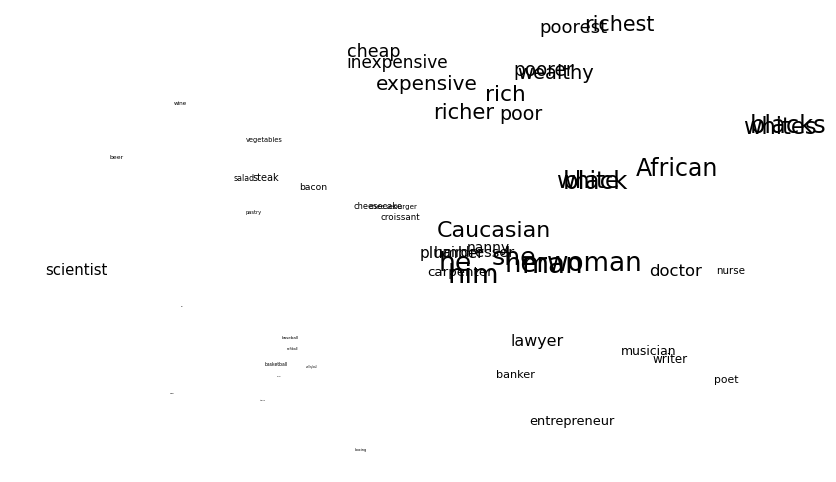

In [100]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111)
ax.set_frame_on(False)
plt.scatter(tsneWordsNYT[:, 0], tsneWordsNYT[:, 1], alpha = 0) #Making the points invisible
for i, word in enumerate(tnytTargetWords):
    ax.annotate(word, (tsneWordsNYT[:, 0][i],tsneWordsNYT[:, 1][i]), size =  20 * (len(tnytTargetWords) - i) / len(tnytTargetWords))
plt.xticks(())
plt.yticks(())
plt.show()

Define some convenient functions for getting dimensions. 

In [101]:
def normalize(vector):
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def dimension(model, positives, negatives):
    diff = sum([normalize(model[x]) for x in positives]) - sum([normalize(model[y]) for y in negatives])
    return diff

Let's calculate three dimensions: gender, race, and class.

In [102]:
Gender = dimension(nytimes_model, ['man','him','he'], ['woman', 'her', 'she'])
Race = dimension(nytimes_model, ['black','blacks','African'], ['white', 'whites', 'Caucasian'])
Class = dimension(nytimes_model, ['rich', 'richer', 'richest', 'expensive', 'wealthy'], ['poor', 'poorer', 'poorest', 'cheap', 'inexpensive'])

Here we have some words.

In [103]:
Occupations = ["doctor","lawyer","plumber","scientist","hairdresser", "nanny","carpenter","entrepreneur","musician","writer", "banker","poet","nurse"]

Foods = ["steak", "bacon", "croissant", "cheesecake", "salad", "cheeseburger", "vegetables", "beer", "wine", "pastry"]

Sports  = ["basketball", "baseball", "boxing", "softball", "volleyball", "tennis", "golf", "hockey", "soccer"]

Define a function to project words in a word list to each of the three dimensions.

In [ ]:
def makeDF(word_list):
    g = []
    r = []
    c = []
    for word in word_list:
        g.append(cosine_similarity(nytimes_model[word].reshape(1,-1), Gender.reshape(1,-1))[0][0])
        r.append(cosine_similarity(nytimes_model[word].reshape(1,-1), Race.reshape(1,-1))[0][0])
        c.append(cosine_similarity(nytimes_model[word].reshape(1,-1), Class.reshape(1,-1))[0][0])
    df = pd.DataFrame({'gender': g, 'race': r, 'class': c}, index = word_list)
    return df

Get the projections.

In [105]:
OCCdf = makeDF(nytimes_model, Occupations) 
Fooddf = makeDF(nytimes_model, Foods)
Sportsdf = makeDF(nytimes_model, Sports)

Define some useful functions for plotting.

In [ ]:
def Coloring(Series):
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax, df, dim):
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim].iloc[i]), color = colors[i], alpha = 0.6, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

Plot the occupational words in each of the three dimensions.

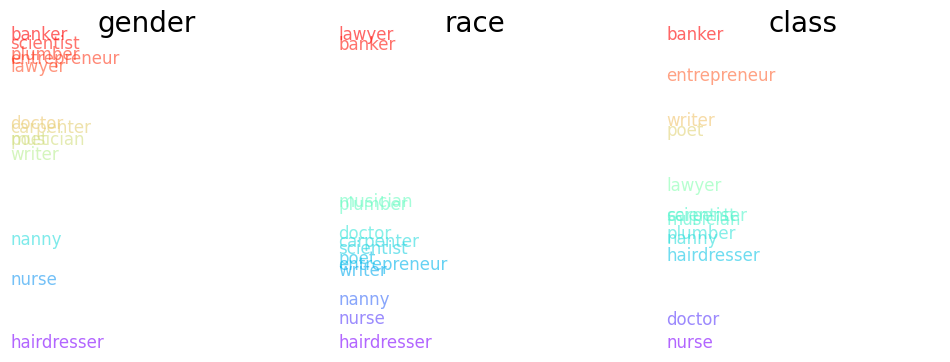

In [111]:
fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, OCCdf, 'gender')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, OCCdf, 'race')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, OCCdf, 'class')
plt.show()

Foods:

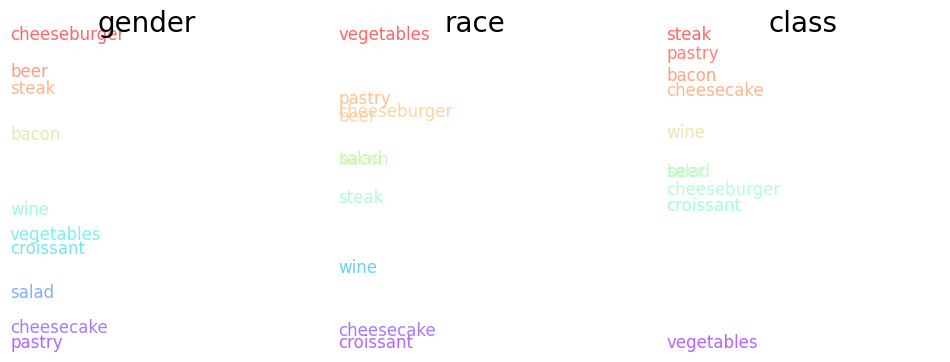

In [112]:
fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, Fooddf, 'gender')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, Fooddf, 'race')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, Fooddf, 'class')
plt.show()

Sports:

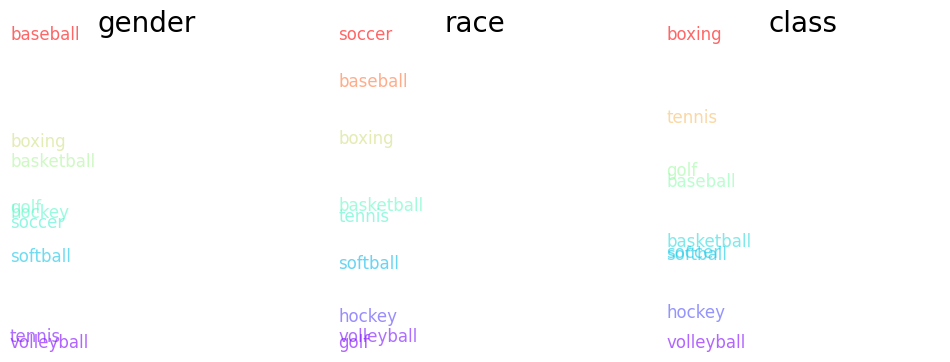

In [113]:
fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, Sportsdf, 'gender')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, Sportsdf, 'race')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, Sportsdf, 'class')
plt.show()

## Your Turn!

To-do:
1. Identify semantic dimensions of interest from your data (e.g., gender: man-woman) and project words onto these dimensions.
1. Plot the array of relevant words along each semantic dimension.

Reflection:
- Which dimensions are most different?
- On which dimension are your words most different? Print three short textual examples from the corpus that illustrate the association you have explored.

### **Stretch**

To-do:
1. Project *documents* from your corpus along a dimension of interest.
1. Sample relevant documents from your corpus with this functionality and explain your rationale.
1. Calculate the cosine of the angle between two dimensions (encoded as vectors) of interest. What does this suggest about the relationship between them within your corpus? 

### **Super stretch**

To-do:
1. Create 90% bootstrap confidence intervals around your word projections onto a given dimension by generating 10 separate word2vec models, sampling $n$ documents (the total number in your corpus) for each, but with replacement.
1. The bounds will be defined as the highest and lowest projection across your 10 samples. Which words are *significantly* different on your semantic dimension of interest?